In [1]:
from io import BytesIO
from pathlib import Path
import os
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
warnings.filterwarnings(
    "ignore",
    message="Pandas requires version .* or newer of 'numexpr'",
    category=UserWarning,
)
import pandas as pd
from IPython.display import Image, display
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import FormatStrFormatter


# Override GHIST_BUNDLE_ROOT when the downloaded bundle is stored elsewhere.
BUNDLE_ROOT = Path(os.getenv("GHIST_BUNDLE_ROOT") or "../bundle").expanduser()
FIGURE_DATA = BUNDLE_ROOT / "figure_data/figure5"
FILES = {
    "paired_pcc": FIGURE_DATA / "paired_gene_pcc.csv",
    "coverage": FIGURE_DATA / "coverage_summary.csv",
}

DIRECTIONS = [
    ("Pancreas 1 → Pancreas 3", "PancreasADC1 → PancreasADC3"),
    ("Breast 1 → Breast 5k", "BreastCancer1 → Breast5k"),
    ("Lung 1 → Lung 5k", "LungADC1 → Lung5k"),
]
GENE_SETS = ["Top 20", "Top 50"]
MODELS = [
    ("Single-slide", "Single_slide_PCC", "#D1495B", -0.18),
    ("PanCancer", "PanCancer_PCC", "#4C8DB8", 0.18),
]


def apply_figure_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans", "sans-serif"],
        "font.size": 12,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.frameon": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    })


apply_figure_style()


In [2]:
def require_columns(frame, columns, label):
    missing = sorted(set(columns).difference(frame.columns))
    if missing:
        raise ValueError(f"{label}: missing columns {missing}")


def display_figure(fig, dpi=300):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, facecolor="white")
    plt.close(fig)
    display(Image(data=buffer.getvalue(), format="png"))


def facet_strip(axis, label):
    axis.add_patch(Rectangle(
        (0, 1.0), 1, 0.10,
        transform=axis.transAxes,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        clip_on=False,
    ))
    axis.text(
        0.5, 1.05, label,
        transform=axis.transAxes,
        ha="center", va="center",
        fontsize=9, fontweight="bold",
        linespacing=0.9,
    )


def plot_figure5(paired):
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.5), sharey=True)
    base_positions = np.array([1.0, 2.0])

    for panel_index, (axis, (direction, label)) in enumerate(zip(axes, DIRECTIONS)):
        panel = paired.loc[paired["Direction"].eq(direction)]

        for model_label, value_column, colour, offset in MODELS:
            values = [
                panel.loc[panel["Gene_set"].eq(gene_set), value_column].to_numpy()
                for gene_set in GENE_SETS
            ]
            if not all(len(group) > 0 for group in values):
                raise ValueError(f"{direction}: missing plotted genes for {model_label}")
            axis.boxplot(
                values,
                positions=base_positions + offset,
                widths=0.28,
                patch_artist=True,
                whis=1.5,
                showfliers=True,
                boxprops={"facecolor": colour, "edgecolor": "#333333", "linewidth": 0.8},
                medianprops={"color": "#333333", "linewidth": 1.0},
                whiskerprops={"color": "#333333", "linewidth": 0.8},
                capprops={"linewidth": 0},
                flierprops={
                    "marker": "o",
                    "markersize": 3.2,
                    "markerfacecolor": colour,
                    "markeredgecolor": "#333333",
                    "markeredgewidth": 0.7,
                },
            )

        axis.set_xlim(0.5, 2.5)
        axis.set_ylim(-0.12, 0.95)
        axis.set_xticks(base_positions, GENE_SETS)
        axis.set_yticks(np.arange(-0.05, 0.96, 0.10))
        axis.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        axis.tick_params(axis="both", length=4, width=0.8, labelsize=10)
        for spine in axis.spines.values():
            spine.set_color("#333333")
            spine.set_linewidth(0.8)
        facet_strip(axis, f"{label}\nSVGs")

        if panel_index > 0:
            axis.tick_params(axis="y", left=False, labelleft=False)

    axes[0].set_ylabel("PCC", fontsize=12, labelpad=8)
    legend_handles = [
        Patch(facecolor=colour, edgecolor="#333333", linewidth=0.8, label=label)
        for label, _, colour, _ in MODELS
    ]
    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.84, 0.52),
        fontsize=10,
        handlelength=1.6,
        handleheight=0.9,
        labelspacing=0.7,
    )
    fig.subplots_adjust(left=0.07, right=0.83, bottom=0.15, top=0.86, wspace=0.025)
    return fig


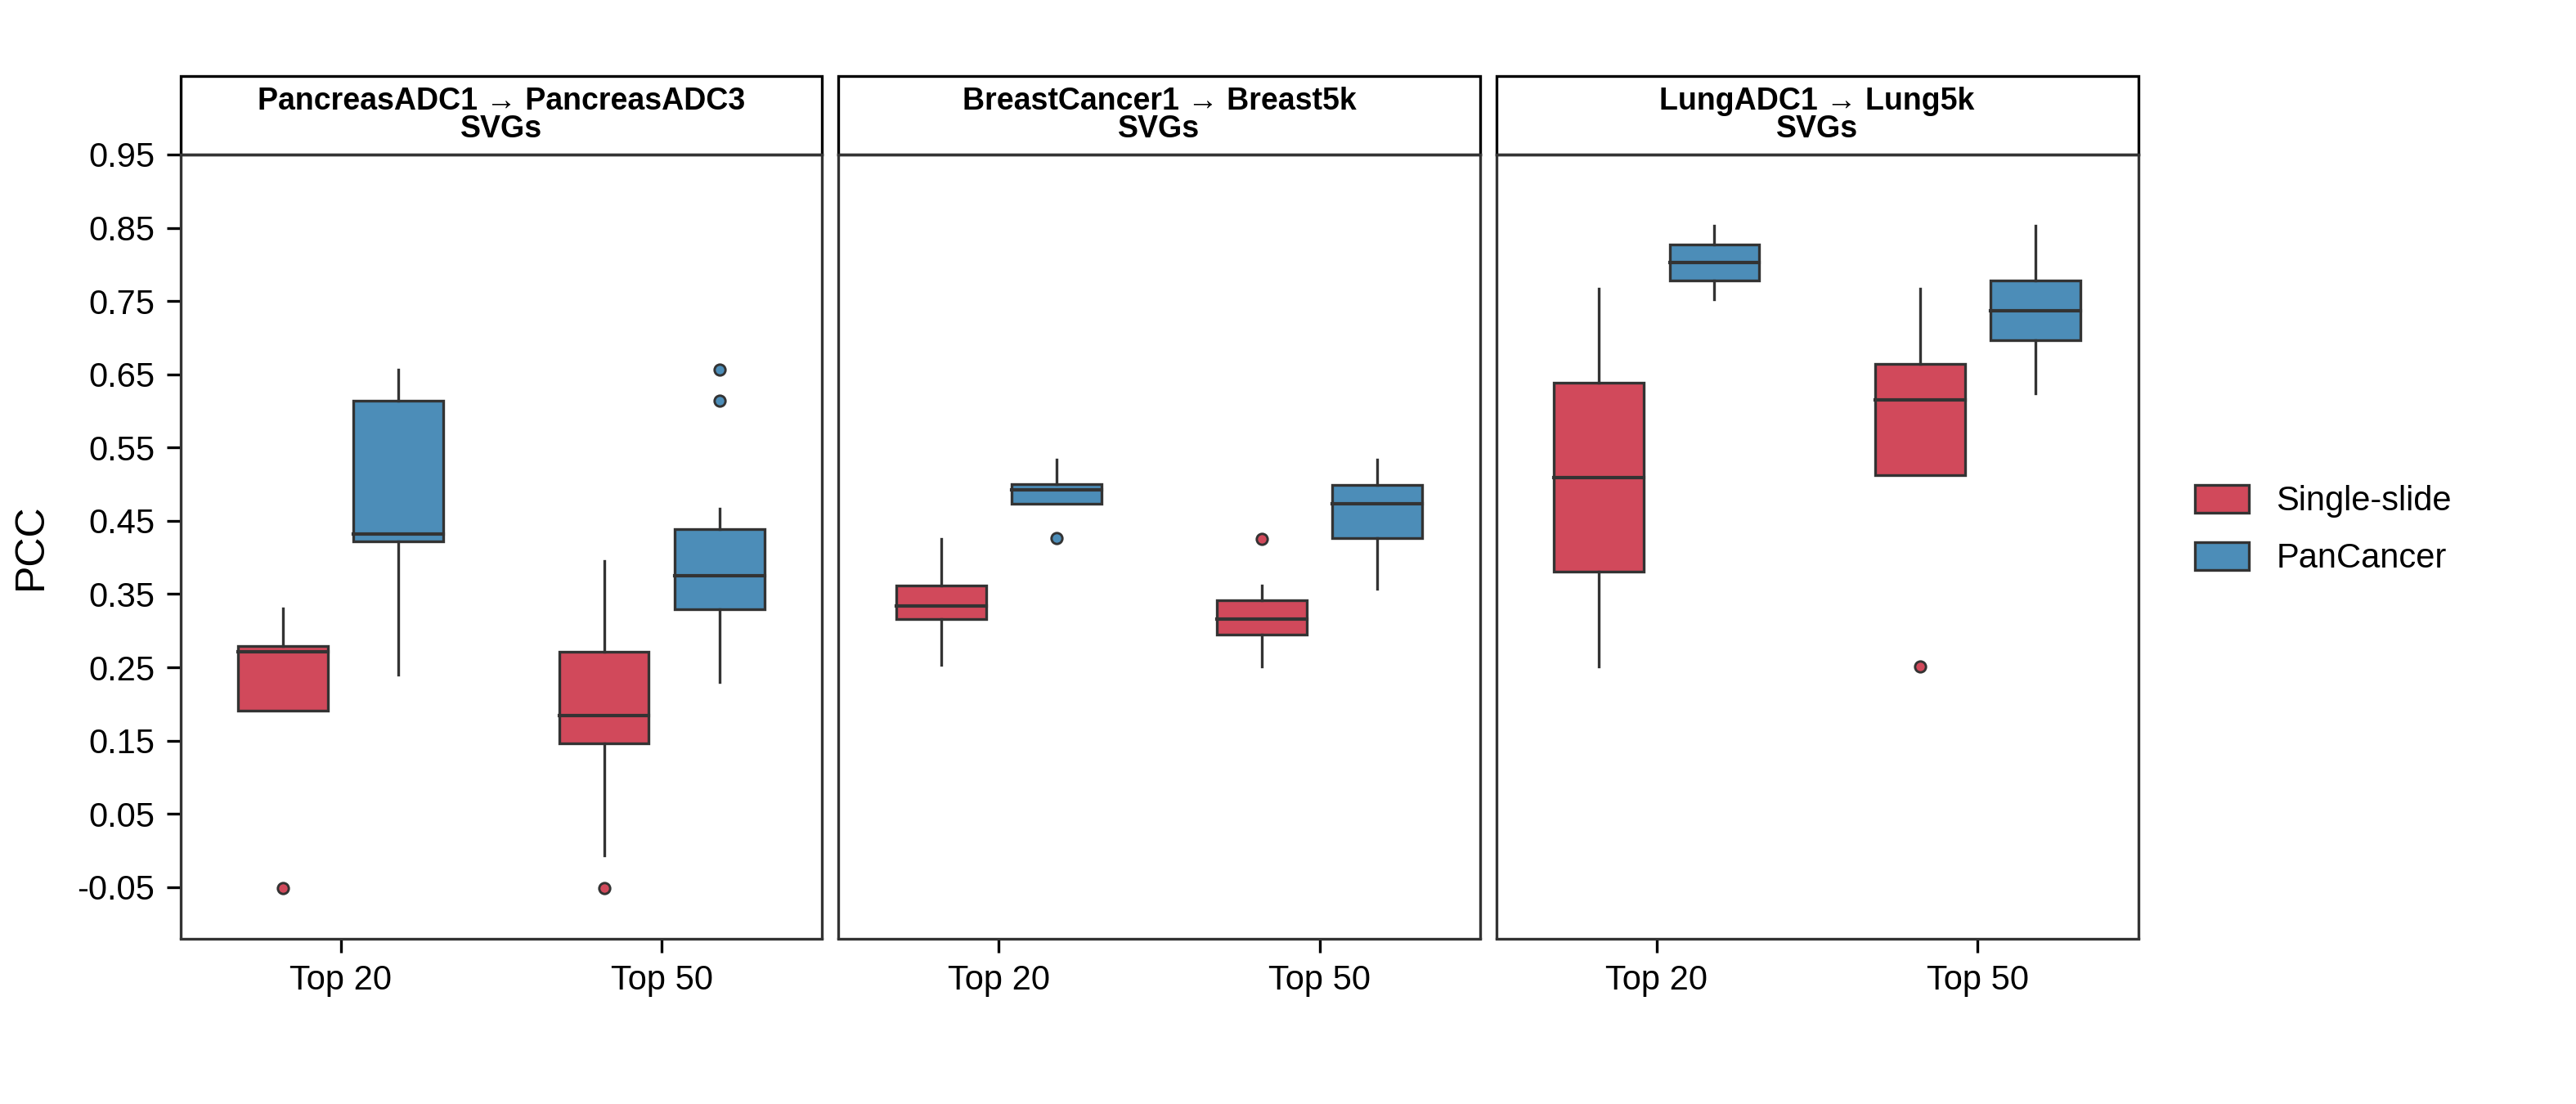

In [3]:
paired = pd.read_csv(FILES["paired_pcc"])
coverage = pd.read_csv(FILES["coverage"])
require_columns(
    paired,
    [
        "Direction", "Gene_set", "Gene", "SVG_rank",
        "Single_slide_PCC", "PanCancer_PCC", "n_cells",
    ],
    "Figure 5 paired PCC",
)
require_columns(
    coverage,
    [
        "Direction", "Gene_set", "target_n", "paired_n",
        "single_valid", "pancancer_valid",
    ],
    "Figure 5 coverage",
)

expected_directions = {direction for direction, _ in DIRECTIONS}
if set(paired["Direction"]) != expected_directions:
    raise ValueError("Figure 5 directions do not match the expected three case studies")
if set(paired["Gene_set"]) != set(GENE_SETS):
    raise ValueError("Figure 5 gene sets must be Top 20 and Top 50")
if paired.duplicated(["Direction", "Gene_set", "Gene"]).any():
    raise ValueError("Figure 5 paired PCC data contain duplicate genes")
if not paired[["Single_slide_PCC", "PanCancer_PCC"]].apply(np.isfinite).all().all():
    raise ValueError("Figure 5 paired PCC data contain undefined values")

observed_counts = paired.groupby(["Direction", "Gene_set"]).size().sort_index()
expected_counts = coverage.set_index(["Direction", "Gene_set"])["paired_n"].sort_index()
if not observed_counts.equals(expected_counts):
    raise ValueError("Figure 5 plotted-gene counts do not match the coverage audit")

display_figure(plot_figure5(paired))
